# 1.Data Loading & Exploration

In [1]:
# Import library
import pandas as pd
import numpy as np

In [2]:
# This one is origninal we don't apply any changes in this
df_O = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [3]:
# Load the Data
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [4]:
# First 10 rows
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [5]:
df.shape

(1470, 35)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1470
Columns: 35


In [8]:
# Input and target columns
print("Input:", df.drop(columns=['Attrition']).columns)
print("Target : Attrition")

Input: Index(['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18',
       'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')
Target : Attrition


In [9]:
Target = df['Attrition']
Target

0       Yes
1        No
2       Yes
3        No
4        No
       ... 
1465     No
1466     No
1467     No
1468     No
1469     No
Name: Attrition, Length: 1470, dtype: str

In [10]:
# Count of employees left vs stayed 
No, Yes = df['Attrition'].value_counts()
print("Left : ", Yes)
print("Stayed : ", No)

Left :  237
Stayed :  1233


In [11]:
# Attrition rate as a percentage
attrition_rate = (Yes/(Yes+No))*100
attrition_rate

16.122448979591837

- The dataset have approximate 16% of employees left the company while approximately 84% stayed, This shows that the dataset is imbalanced, with the majority of employees staying in the organization.
- Such class imbalance should be considered during model evaluation to ensure the model can accurately identify employees who are going to leave.

In [12]:
# how many columns are numeric vs categorical
Numeric, Categorical = df.dtypes.value_counts()
print("Numeric_columns : ", Numeric)
print("Categorical_columns : ", Categorical)

Numeric_columns :  26
Categorical_columns :  9


# 2.Data Cleaning

In [13]:
# Check for missing/null values
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

- There is no Missing values in this dataset

In [14]:
print(df["Over18"].value_counts())
print(df['StandardHours'].value_counts())
print(df['EmployeeCount'].value_counts())

Over18
Y    1470
Name: count, dtype: int64
StandardHours
80    1470
Name: count, dtype: int64
EmployeeCount
1    1470
Name: count, dtype: int64


- As we see the columns Over18, StandardHours, and EmployeeCount are constant for everyone in the dataset thats why these columns are useless, They don't add any value to prediction

In [15]:
df['EmployeeNumber']

0          1
1          2
2          4
3          5
4          7
        ... 
1465    2061
1466    2062
1467    2064
1468    2065
1469    2068
Name: EmployeeNumber, Length: 1470, dtype: int64

- EmployeeNumber this column only contains an ID number of every Employee this column is also useless , So it will not add any value to prediction

In [16]:
# Droping columns that add no value to prediction
df.drop(columns=['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18'], inplace=True)

In [17]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [18]:
# Convert the target column Attrition from Yes/No to 1/0
df['Attrition'] = df['Attrition'].map({
    'Yes':1,
    'No':0
})

In [19]:
# Encoding all remaining categorical columns using One-Hot Encoding
df = pd.get_dummies(df, drop_first=True, dtype=int)

In [20]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,0,0,0,0,0,1,0,0,1,1
1,49,0,279,8,1,3,61,2,2,2,...,0,0,0,0,1,0,0,1,0,0
2,37,1,1373,2,2,4,92,2,1,3,...,1,0,0,0,0,0,0,0,1,1
3,33,0,1392,3,4,4,56,3,1,3,...,0,0,0,0,1,0,0,1,0,1
4,27,0,591,2,1,1,40,3,1,2,...,1,0,0,0,0,0,0,1,0,0


In [21]:
# Scaling numeric features using StandardScaler
from sklearn.preprocessing import StandardScaler

X = df.drop('Attrition', axis = 1)
y = df['Attrition']

stdScaler = StandardScaler()
X_scaled = stdScaler.fit_transform(X)

# 3.Exploratory Data Analysis — EDA


In [22]:
import matplotlib.pyplot as plt 
import seaborn as sns

## A. Attrition rate by Department

In [23]:
dept_attrition = pd.crosstab(
    df_O['Department'],
    df_O['Attrition'],
    normalize='index'
) * 100
dept_attrition

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


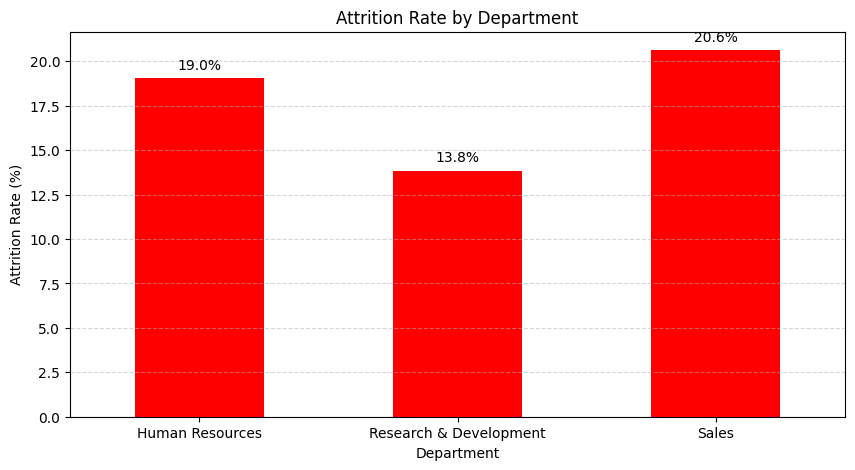

In [24]:
# Barplot
dept_attrition['Yes'].plot(kind='bar', figsize=(10,5), color=['red'])

plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add percentage labels on each bar
for i, v in enumerate(dept_attrition['Yes']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.show()

A. which department loses the most employees?

- Accoring to above observations Sales department loses the most employees.

## B. Attrition rate by Job Role

In [25]:
# Crosstab for summery
jobrole_attrition = pd.crosstab(
    df_O['JobRole'],
    df_O['Attrition'],
    normalize='index'
) * 100
jobrole_attrition

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


C:\Users\Shubham Meena\AppData\Local\Temp\ipykernel_17688\2485024968.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=jobrole_attrition['Yes'].values, y=jobrole_attrition.index, palette='viridis')


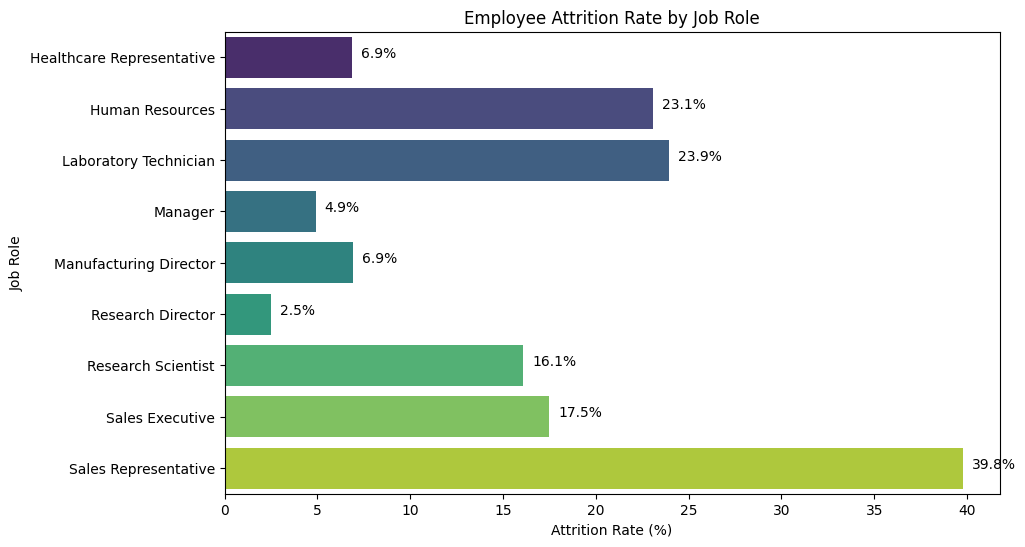

In [26]:
# Barplot
plt.figure(figsize=(10,6))

sns.barplot(x=jobrole_attrition['Yes'].values, y=jobrole_attrition.index, palette='viridis')

plt.title('Employee Attrition Rate by Job Role')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')

# Add percentage labels on each bar
for i, value in enumerate(jobrole_attrition['Yes']):
    plt.text(value + 0.5, i, f'{value:.1f}%')

plt.show()

B. which roles have the highest exit rate?
- Sales Representatives have the highest attrition rate (39.76%), which is significantly higher than all other job roles.
- Laboratory Technicians (23.94%) and Human Resources (23.08%) also experience relatively high attrition.
- Research Directors (2.50%) and Managers (4.90%) have the lowest attrition rates, indicating better employee retention.

## C. Attrition vs Monthly Income

C:\Users\Shubham Meena\AppData\Local\Temp\ipykernel_17688\3214095936.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df_O, x='Attrition', y='MonthlyIncome', palette='Set2')


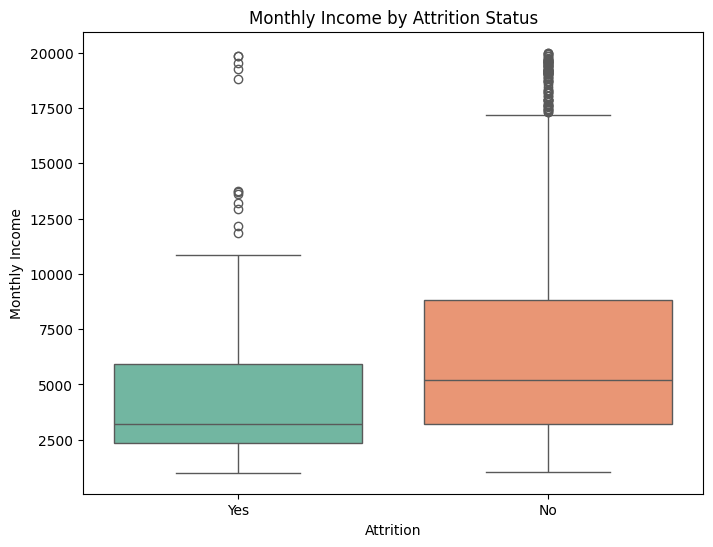

In [27]:
# Boxplot
plt.figure(figsize=(8,6))

sns.boxplot(df_O, x='Attrition', y='MonthlyIncome', palette='Set2')

plt.title('Monthly Income by Attrition Status')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')

plt.show()

C. Do lower paid employees leave more?

- Yes, Employees who leave more the company generally had a lower monthly income than employees who stayed. The median income of employees who left is noticeably lower, suggesting that lower salary may contribute to higher attrition.

## D. Attrition vs Work-Life Balance rating 

In [28]:
# Crosstab for summery
worklb_attrition = pd.crosstab(
    df_O['WorkLifeBalance'],
    df_O['Attrition'],
    normalize='index'
) * 100

worklb_attrition

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


<Figure size 800x600 with 0 Axes>

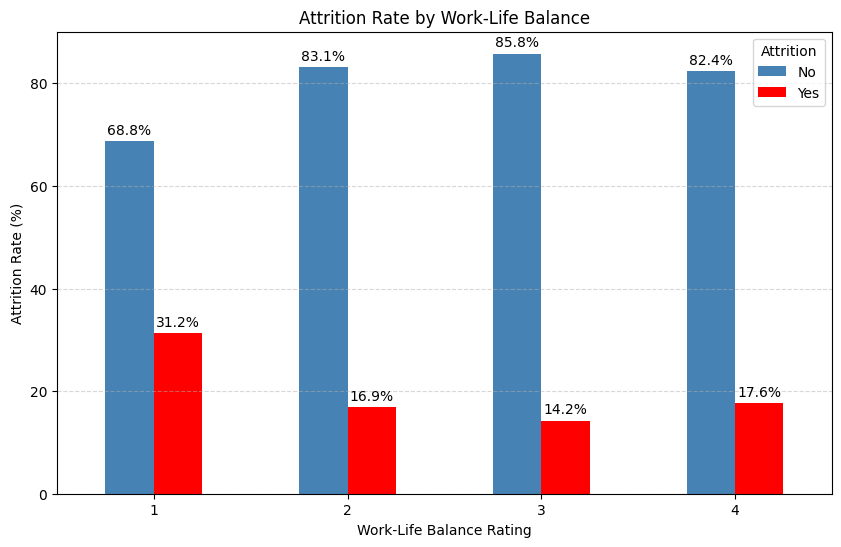

In [29]:
# Barplot
plt.figure(figsize=(8,6))

ax = worklb_attrition.plot(kind='bar',figsize=(10,6),color=['steelblue', 'red'])

plt.title('Attrition Rate by Work-Life Balance')
plt.xlabel('Work-Life Balance Rating')
plt.ylabel('Attrition Rate (%)')
plt.legend(title='Attrition')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add percentage labels on each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3,
        fontsize=10
    )
    
plt.show()

D. Is there a visible pattern?
- A clear relationship can be seen between work-life balance and employee attrition. Employees with a Work-Life Balance rating of 1 have the highest attrition rate (31.2%), indicating that poor work-life balance is strongly associated with employees leaving the company. As the rating improves to 2 and 3, the attrition rate decreases to 16.9% and 14.2%, respectively. Although the attrition rate increases slightly to 17.6% at rating 4, it is still much lower than rating 1. Overall, employees with better work-life balance are less likely to leave the organization.

## E. Attrition vs Years at Company 

In [30]:

# Create tenure groups
df_O['Tenure Group'] = pd.cut(
    df_O['YearsAtCompany'],
    bins=[-1, 2, 5, 10, 20, 40],
    labels=['0-2', '3–5', '6–10', '11–20', '21+']
)

# Crosstab for summery
tenure_attrition = pd.crosstab(
    df_O['Tenure Group'],
    df_O['Attrition'],
    normalize='index'
) * 100

tenure_attrition

Attrition,No,Yes
Tenure Group,,
0-2,70.175439,29.824561
3–5,86.175115,13.824885
6–10,87.723214,12.276786
11–20,93.333333,6.666667
21+,87.878788,12.121212


<Figure size 1000x600 with 0 Axes>

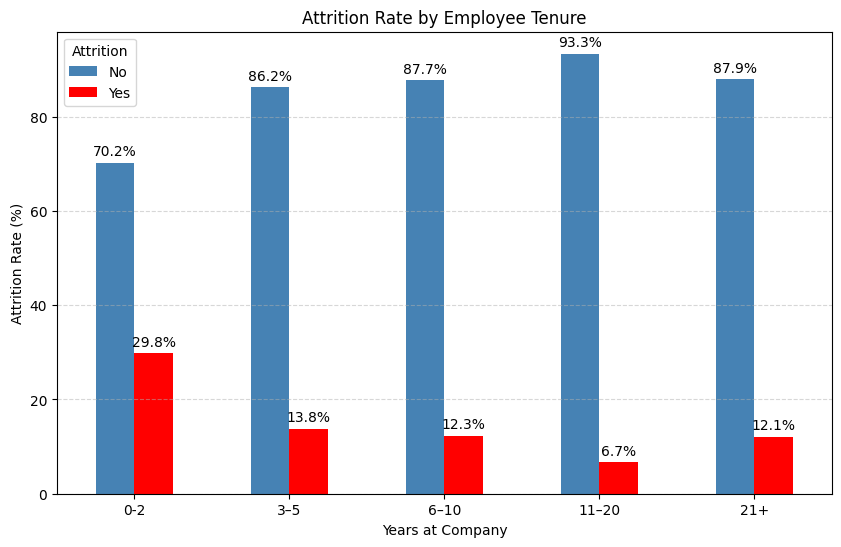

In [31]:
# Barplot
plt.figure(figsize=(10,6))

ax = tenure_attrition.plot(kind='bar', figsize=(10,6), color=['steelblue', 'red'])

plt.title('Attrition Rate by Employee Tenure')
plt.xlabel('Years at Company')
plt.ylabel('Attrition Rate (%)')

plt.legend(title='Attrition')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3,
        fontsize=10
    )

plt.show()

E.  At what point in tenure do employees leave most?
- The graph shows that employees are most likely to leave during their first 0–2 years at the company, with an attrition rate of 29.8%. As employees spend more time in the organization, the attrition rate gradually decreases to 13.8% (3–5 years), 12.3% (6–10 years), and reaches its lowest value of 6.7% (11–20 years). Although the attrition rate rises slightly to 12.1% for employees with more than 21 years of service, it is still much lower than that of new employees. This suggests that employees who stay with the company for longer are generally less likely to leave.

### Business Insights from EDA

**1. Sales employees are at the highest risk of leaving.**
The Sales department has the highest attrition rate (**20.6%**), followed by Human Resources (**19.0%**), while Research & Development has the lowest attrition rate (**13.8%**). This suggests that employee retention strategies should be prioritized in the Sales department.

**2. Sales Representatives experience exceptionally high turnover.**
Among all job roles, **Sales Representatives have the highest attrition rate (39.8%)**, which is nearly **16 percentage points higher** than Laboratory Technicians (**23.9%**) and much higher than Research Directors (**2.5%**). This indicates that Sales Representatives are the most vulnerable employee group and require targeted retention initiatives.

**3. Lower salary is associated with higher employee attrition, but it is not the only factor.**
The box plot shows that employees who left generally had a lower monthly income than those who stayed. However, the presence of several high-income employees among those who resigned indicates that salary alone cannot explain attrition, and factors such as work-life balance and job satisfaction should also be considered.

**4. Poor work-life balance significantly increases the likelihood of attrition.**
Employees with a **Work-Life Balance rating of 1** have an attrition rate of **31.2%**, which is more than **double** the attrition rate of employees with a rating of **3 (14.2%)**. This highlights work-life balance as an important factor influencing employee retention.

**5. Most employees leave during their first two years with the company.**
Employees with **0–2 years** of service have the highest attrition rate (**29.8%**), while employees with **11–20 years** of service have the lowest attrition rate (**6.7%**). This indicates that the first two years of employment are the most critical period for retaining employees and should receive the greatest HR attention.


# 4. Model Building & Comparison

In [32]:
# Spliting Without scaled for some models
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [33]:
# Spliting data into training and test sets (80/20)
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [35]:
# Logistic Regression
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=100)

lr.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default

In [36]:
# Random Forest
rf = RandomForestClassifier( n_estimators=300, class_weight='balanced', random_state=42)

rf.fit(X_train, y_train)
# there is no need of scalling

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [37]:
# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200,learning_rate=0.05, max_depth=3, random_state=42)
# gb = GradientBoostingClassifier( random_state=42)

gb.fit(X_train, y_train)
# there is no need of scalling

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (i

In [38]:
# Predictions
y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)

In [39]:
# Predicted Probabilities (Needed for ROC-AUC)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_gb = gb.predict_proba(X_test)[:, 1]

In [40]:
# Import Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [41]:
# Comparison Table
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb)
    ]
})

comparison = comparison.round(3)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.748,0.341,0.617,0.439,0.799
1,Random Forest,0.837,0.484,0.319,0.385,0.777
2,Gradient Boosting,0.850,0.588,0.213,0.312,0.804


### Three classification models—Logistic Regression, Random Forest, and Gradient Boosting—were trained and evaluated using an 80:20 train-test split. Since the dataset is imbalanced, the class_weight='balanced' parameter was used for Logistic Regression and Random Forest to improve the model's ability to identify employees who are likely to leave

### Here we get same results for Random Forest and Gradient Boosting with or without scaling thats why we did not use scaling in this 

# 5. Model Evaluation


In [42]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_gb = confusion_matrix(y_test, y_pred_gb)

In [43]:
# Linear Regression
cm_lr   

array([[191,  56],
       [ 18,  29]])

In [44]:
# Random Forest
cm_rf

array([[231,  16],
       [ 32,  15]])

In [45]:
# Gradient Boosting
cm_gb

array([[240,   7],
       [ 37,  10]])

##  A. which model performed best and why?
- Although Gradient Boosting achieved the highest Accuracy (85.0%), Precision (58.8%), and ROC-AUC (0.804), it correctly identified only 21.3% of employees who actually left the company. Since the primary objective of employee attrition prediction is to identify employees who are likely to leave, Recall is the most important evaluation metric. Logistic Regression achieved the highest Recall (61.7%) and F1-Score (43.9%), making it the most suitable model for this problem. Therefore, Logistic Regression was selected as the best-performing model because it is more effective at identifying employees at risk of attrition, allowing HR teams to take timely retention actions.

- Logistic Regression is best performing model for this problem 

## B. Recall Meaning and why it Matters

Employee attrition prediction is an **imbalanced classification problem**, where the main objective is to identify employees who are likely to leave the company. In such cases, **Recall** is a more important evaluation metric than Accuracy because it measures how many actual employees who left were correctly identified by the model.

To understand this, imagine that **100 employees are actually planning to leave the company**:

| Model | Employees Correctly Identified (out of 100) |
|:----------------------|:------------------------------------------:|
| Logistic Regression | **62** |
| Random Forest | **32** |
| Gradient Boosting | **21** |

Although **Gradient Boosting** achieved the highest Accuracy (**85.0%**), it correctly identifies only about **21 out of every 100 employees** who are likely to leave. In contrast, **Logistic Regression** correctly identifies approximately **62 out of every 100 employees**, making it much more effective for employee attrition prediction.

Since the primary goal of HR is to identify employees at risk of leaving and take preventive actions, **Logistic Regression is the preferred model** despite its lower overall accuracy. Missing an employee who is likely to resign (False Negative) can result in the loss of valuable talent, increased recruitment costs, and reduced productivity. Therefore, **Recall is the most important metric for this problem.**

## C. Which factors matter most in predicting attrition?
- Since Logistic Regression is best model, feature importance is obtained from its coefficients (coef_)

In [46]:
# Extract Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(lr.coef_[0])   # Absolute coefficient values
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
34,JobRole_Laboratory Technician,0.797874
43,OverTime_Yes,0.766412
23,BusinessTravel_Travel_Frequently,0.719335
7,JobLevel,0.659189
16,TotalWorkingYears,0.656931
40,JobRole_Sales Representative,0.552515
24,BusinessTravel_Travel_Rarely,0.511649
27,EducationField_Life Sciences,0.506505
21,YearsSinceLastPromotion,0.500389
26,Department_Sales,0.481690


C:\Users\Shubham Meena\AppData\Local\Temp\ipykernel_17688\8891037.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


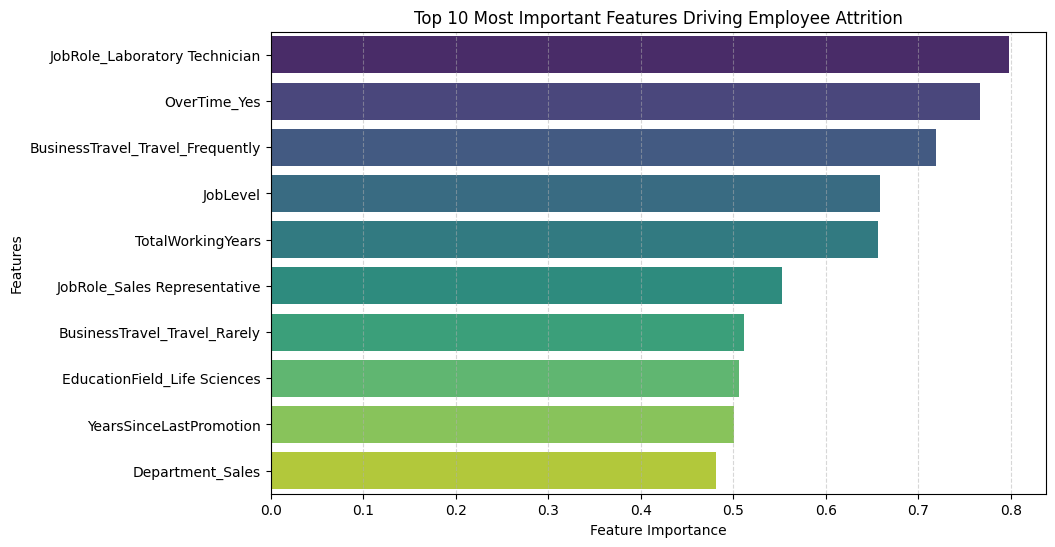

In [47]:
# Plot top 10 features
top10 = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title('Top 10 Most Important Features Driving Employee Attrition')
plt.xlabel('Feature Importance')
plt.ylabel('Features')

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

## D. Rank the Top 10 Features

In [48]:
top10.reset_index(drop=True)

,Feature,Importance
0,JobRole_Laboratory Technician,0.797874
1,OverTime_Yes,0.766412
2,BusinessTravel_Travel_Frequently,0.719335
3,JobLevel,0.659189
4,TotalWorkingYears,0.656931
5,JobRole_Sales Representative,0.552515
6,BusinessTravel_Travel_Rarely,0.511649
7,EducationField_Life Sciences,0.506505
8,YearsSinceLastPromotion,0.500389
9,Department_Sales,0.481690


| Rank | Feature                          | Importance | Interpretation                                                                                                                         |
| ---- | -------------------------------- | ---------: | -------------------------------------------------------------------------------------------------------------------------------------- |
| 1    | JobRole_Laboratory Technician    |      0.798 | Laboratory Technicians are more likely to leave the company than many other job roles.                                                 |
| 2    | OverTime_Yes                     |      0.766 | Employees who work overtime have a significantly higher risk of attrition.                                                             |
| 3    | BusinessTravel_Travel_Frequently |      0.719 | Frequent business travel is strongly associated with employees leaving the organization.                                               |
| 4    | JobLevel                         |      0.659 | An employee's job level has a strong influence on attrition, indicating that career progression and responsibilities affect retention. |
| 5    | TotalWorkingYears                |      0.657 | Employees with different levels of overall work experience show different attrition patterns.                                          |
| 6    | JobRole_Sales Representative     |      0.553 | Sales Representatives are among the most likely employees to leave the company.                                                        |
| 7    | BusinessTravel_Travel_Rarely     |      0.512 | Business travel frequency influences attrition, although employees who travel rarely have a lower impact than frequent travelers.      |
| 8    | EducationField_Life Sciences     |      0.507 | Employees from the Life Sciences education background show a noticeable influence on attrition prediction.                             |
| 9    | YearsSinceLastPromotion          |      0.500 | Employees who have not received a promotion for a long time are more likely to leave.                                                  |
| 10   | Department_Sales                 |      0.482 | Employees working in the Sales department have a higher likelihood of attrition than employees in other departments.                   |


- ## Top 10 Features Driving Employee Attrition

The Logistic Regression model identified several important factors that influence employee attrition. The most influential feature was **Job Role (Laboratory Technician)**, indicating that employees in this role are more likely to leave the company. **Overtime** was the second most important factor, suggesting that employees who frequently work overtime are at a higher risk of attrition.

Frequent **business travel** also showed a strong influence on employee turnover, while **job level** and **total working experience** were found to be important career-related factors. Employees who had **not received a promotion for a long time** were also more likely to leave the organization. Additionally, employees working in the **Sales department** and **Sales Representative** role showed a higher likelihood of attrition.

These findings suggest that employee workload, career growth opportunities, travel requirements, and specific job roles play a major role in predicting employee attrition.

EDA shows individual relationships between each feature and attrition, whereas Logistic Regression measures the contribution of each feature while considering all other variables simultaneously. Therefore, the most important features in the model may differ from the strongest patterns observed during EDA

# 6. Visualization

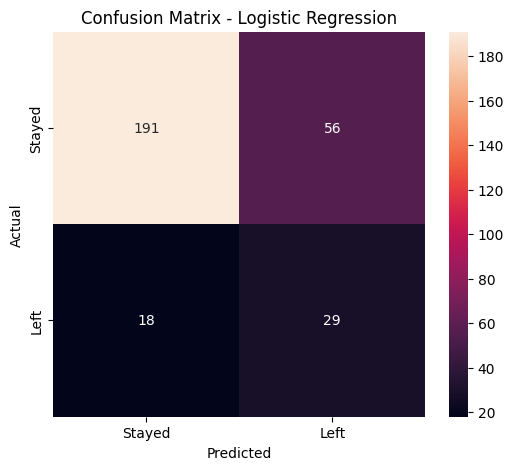

In [ ]:
#  Confusion Matrix heatmap for your best model

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    xticklabels=['Stayed', 'Left'],
    yticklabels=['Stayed', 'Left']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

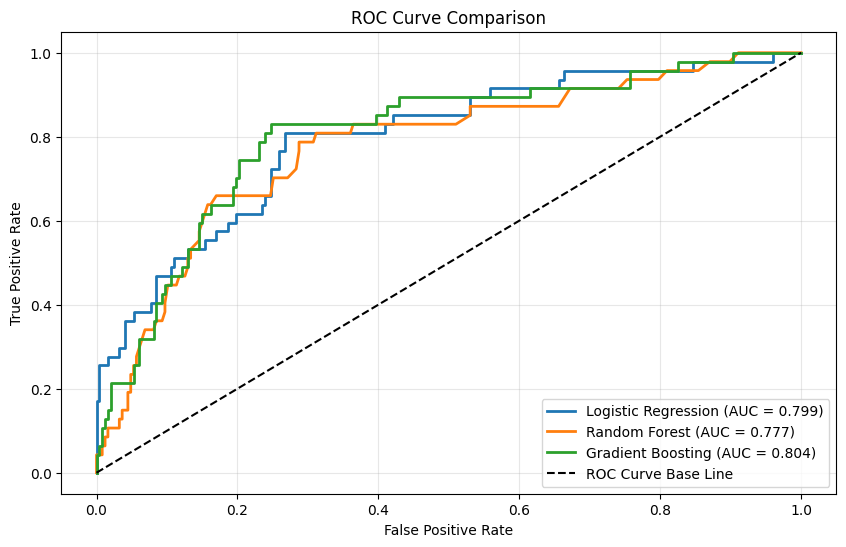

In [64]:
# ROC Curve comparing all 3 models on one graph

from sklearn.metrics import roc_curve

# ROC values
# fpr : False Positive Rate
# tpr : True Positive Rate
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.figure(figsize=(10,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    linewidth=2,
    label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})'
)

plt.plot(
    fpr_gb,
    tpr_gb,
    linewidth=2,
    label=f'Gradient Boosting (AUC = {roc_auc_score(y_test, y_prob_gb):.3f})'
)

# Base line
plt.plot([0,1],[0,1],'k--',label='ROC Curve Base Line')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### ROC Curve Analysis

The ROC Curve compares the ability of all three models to distinguish between employees who are likely to leave and those who are likely to stay. A model with a curve closer to the top-left corner and a higher Area Under the Curve (ROC-AUC) score has better classification performance.

From the graph, **Gradient Boosting** achieved the highest ROC-AUC score (**0.804**), followed closely by **Logistic Regression (0.799)** and **Random Forest (0.777)**. Since all three ROC-AUC values are close to **0.80**, each model demonstrates good discrimination ability.

However, although Gradient Boosting has the highest ROC-AUC score, its Recall is only **21.3%**, meaning it fails to identify many employees who are actually likely to leave. In contrast, Logistic Regression achieves a much higher Recall (**61.7%**), making it a more suitable model for employee attrition prediction despite having a slightly lower ROC-AUC score.

# 7. HR Insights & Business Recommendations

### HR Insights

The analysis shows that the three strongest factors influencing employee attrition are **Job Role (especially Laboratory Technician and Sales Representative)**, **working overtime**, and **frequent business travel**. These employees have a much higher likelihood of leaving the company compared to others. In addition, employees who have not been promoted for several years and those with lower job levels also show a higher risk of attrition.

The **Sales department** should be given the highest priority for retention efforts because it has the highest department-level attrition rate (**20.6%**). Among job roles, **Sales Representatives (39.8%)**, **Laboratory Technicians (23.9%)**, and **Human Resources employees (23.1%)** experience the highest turnover and should be the primary focus of HR retention programs.

The analysis also indicates that **salary alone does not explain employee attrition**. Although employees who left generally had lower monthly incomes, factors such as overtime, job role, business travel, work-life balance, promotion opportunities, and career growth had an even stronger influence on whether an employee decided to leave.

### HR Recommendations

1. **Implement targeted retention programs** for high-risk employees, especially Sales Representatives, Laboratory Technicians, employees who frequently work overtime, and those who travel often. Regular one-on-one meetings, flexible work arrangements, and workload management can help reduce employee burnout.

2. **Strengthen career development and promotion planning.** Employees who have gone several years without a promotion should receive regular career discussions, skill development opportunities, and clear promotion pathways to improve engagement and reduce voluntary turnover.

### Model Limitation

Although the Logistic Regression model successfully identified many employees who were likely to leave, it is not perfect. The model is trained using historical employee data and does not consider factors such as personal reasons, company culture, or future organizational changes. Therefore, the model should be used as a **decision-support tool** to help HR identify employees who may need attention, rather than immediately assumes the employee will resign..
